# 02 Physics forward simulator

This notebook builds and checks the physics model of a golf ball's flight, fits its global aerodynamic coefficients to the training shots, and measures how well it predicts apex and landing **when the true launch spin is known**. Spin is an input here, so these results are a ceiling for the physics approach, not a submittable model. Step 6 replaces the true spin with spin inferred from the checkpoints.

## 1. The model

Each shot is simulated in its own tee-centred frame from `01_eda.ipynb`: `d` downrange, `l` lateral (positive left), `h` height, with gravity along `-h`. Per unit mass:

$$\dot{\mathbf v} = -g\,\hat{\mathbf h} - k\,|\mathbf v|\left(C_D\,\mathbf v - C_L\,(\hat{\mathbf s}\times\mathbf v)\right),\qquad k = \frac{\rho A}{2m}$$

with $m = 0.04593$ kg, $d = 0.04267$ m, $g = 9.81$ m/s² and $\rho = 1.2$ kg/m³. Air density is fixed, not fitted, because it multiplies every coefficient and cannot be separated from them.

The coefficients depend on the spin ratio $S = \omega r / |\mathbf v|$: $C_D = c_{d0} + c_{d1} S$, $C_L = c_{l0} S^{c_{l1}}$, and spin decays as $\omega(t) = \omega_0 e^{-t/\tau}$. Spin is given in rpm and converted to rad/s inside the simulator.

**Spin axis.** One tilt angle per shot sets $\hat{\mathbf s} = (0, -\cos\theta, \sin\theta)$. Tilt 0 is pure backspin (lift straight up for a ball moving downrange). Positive tilt curves the ball left, towards positive `l`. `tests/test_physics.py` checks the sign.

**Integrator.** Fitting needs many batch simulations, so `inrange.physics.integrate` runs a fixed-step RK4 on all shots at once. Apex (vertical velocity falls through zero), level landing (height falls back through zero after apex) and positions at each checkpoint time are found by cubic Hermite interpolation inside a step, not by snapping to the grid. A `solve_ivp` reference with event functions (DOP853, tolerances 1e-11) is kept for checking.

In [1]:
import pickle
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from inrange.io import REPO_ROOT, TARGET_COLS, load_test, load_train
from inrange.features import add_sessions, assign_tees, ball_speed, speed_band
from inrange.frame import add_shot_frame
from inrange.physics import TEXTBOOK, Aero, RADIUS, simulate, simulate_reference
from inrange.calibration import (
    FIXED_TAU, GROUPS, _residual_blocks, fit_globals, implied_speed_factor, launch_consistency,
    predict_shot_frame, robust_group_scales, shot_batch, tau_profile,
)
from inrange.models import lgbm_fit_predict, physics_fold_results, replay_fit_predict, OracleSpinPhysics
from inrange.scoring import (
    COMPONENTS, WEIGHTS_WITHOUT_SPIN, compare_results, cross_validate, leave_one_session_out_splits,
    report_table, test_mix_table,
)

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 220, "display.max_columns", 30, "display.precision", 3)

FIG_DIR = REPO_ROOT / "outputs" / "figures"
CACHE_DIR = REPO_ROOT / "data" / "processed"
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
INK, INK_2, GRID, SURFACE = "#0b0b0b", "#52514e", "#e4e3df", "#fcfcfb"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": INK_2, "axes.labelcolor": INK, "text.color": INK,
    "xtick.color": INK_2, "ytick.color": INK_2, "axes.grid": True, "grid.color": GRID,
    "grid.linewidth": 0.8, "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold", "figure.dpi": 110,
    "legend.frameon": False,
})

def save(fig, name):
    fig.savefig(FIG_DIR / f"{name}.png", dpi=150, bbox_inches="tight")

def cached(name, compute):
    # Expensive fits are cached in data/processed (gitignored); delete the file to recompute.
    path = CACHE_DIR / f"{name}.pkl"
    if path.exists():
        with open(path, "rb") as handle:
            return pickle.load(handle)
    value = compute()
    with open(path, "wb") as handle:
        pickle.dump(value, handle)
    return value

train, test = add_sessions(load_train(), load_test())
batch = shot_batch(train)
frame = add_shot_frame(train)
print(f"{batch.n} training shots")

491 training shots


### Integrator accuracy and step size

In [2]:
rng = np.random.default_rng(0)
rows = np.r_[rng.choice(batch.n, 6, replace=False), batch.vel0[:, 0].argmax(), batch.spin_rpm.argmax()]
sample = batch.subset(rows)
tilts = np.radians([-20, -10, -5, 0, 5, 10, 20, 15])
checks = []
for label, aero in [("textbook", TEXTBOOK), ("extreme", Aero(0.35, 0.8, 1.2, 0.2, 3.0))]:
    refs = [simulate_reference(sample.vel0[i], sample.spin_rpm[i], tilts[i], aero, sample.cp_t[i]) for i in range(sample.n)]
    for dt in [0.005, 0.01, 0.02, 0.05]:
        started = time.perf_counter()
        sim = simulate(sample.vel0, sample.spin_rpm, tilts, aero, sample.cp_t, dt=dt)
        pos_err = max(max(np.abs(sim.apex_pos[i] - r["apex_pos"]).max(),
                          np.abs(sim.landing_pos[i] - r["landing_pos"]).max(),
                          np.abs(sim.query_pos[i] - r["query_pos"]).max()) for i, r in enumerate(refs))
        time_err = max(max(abs(sim.apex_t[i] - r["apex_t"]), abs(sim.landing_t[i] - r["landing_t"]))
                       for i, r in enumerate(refs))
        checks.append({"coefficients": label, "dt (s)": dt, "max position error (mm)": pos_err * 1000,
                       "max event time error (ms)": time_err * 1000})
print(pd.DataFrame(checks).to_string(index=False, float_format=lambda v: f"{v:.5f}"))

for dt in [0.01, 0.02]:
    started = time.perf_counter()
    simulate(batch.vel0, batch.spin_rpm, np.zeros(batch.n), TEXTBOOK, batch.cp_t, dt=dt)
    print(f"all {batch.n} shots at dt = {dt} s: {time.perf_counter() - started:.2f} s")

coefficients  dt (s)  max position error (mm)  max event time error (ms)
    textbook 0.00500                  0.00000                    0.00000
    textbook 0.01000                  0.00000                    0.00000
    textbook 0.02000                  0.00001                    0.00000
    textbook 0.05000                  0.00048                    0.00001
     extreme 0.00500                  0.00000                    0.00000
     extreme 0.01000                  0.00004                    0.00000
     extreme 0.02000                  0.00058                    0.00001
     extreme 0.05000                  0.02260                    0.00028


all 491 shots at dt = 0.01 s: 0.33 s
all 491 shots at dt = 0.02 s: 0.16 s


RK4 with Hermite event location agrees with the adaptive reference far inside the required 1 cm and 1 ms at every step tried, including an extreme set of coefficients. The simulator therefore uses **dt = 0.02 s**, which halves the cost of 0.01 s at no measurable loss of accuracy.

## 2. Launch consistency

Step 4 found the deceleration between launch and the first checkpoint spanning -85 to +86 m/s², so the given launch velocity and the checkpoints sometimes disagree. Before fitting anything, drag-only textbook physics is run from each launch state, and its miss at cp1 and cp2 is measured: crossing time (simulated minus observed) and lateral and height position at the observed crossing time.

To judge whether a miss is beyond what physics can explain, each shot is also run with every combination of constant drag coefficient 0.1 or 0.5, lift coefficient 0 or 0.4, and tilt -45°, 0° or +45°. That envelope is far wider than any real golf ball. A shot is **flagged** if its checkpoint timing lies more than 5 ms outside the envelope (about 0.25 m at 50 m/s, well above the interpolation error of a crossing time), or its position more than 0.25 m outside it.

In [3]:
consistency = launch_consistency(batch)
consistency["f1"] = implied_speed_factor(batch, 0)
consistency["f2"] = implied_speed_factor(batch, 1)
consistency["timing_flag"] = consistency[["excess_t_1", "excess_t_2"]].max(axis=1) > 0.005
consistency["position_flag"] = consistency[["excess_pos_1", "excess_pos_2"]].max(axis=1) > 0.25
consistency["flag"] = consistency["timing_flag"] | consistency["position_flag"]
consistency["session"] = train["session"]
consistency["tee"] = assign_tees(train)
consistency["speed_band"] = speed_band(train)
consistency["ball_speed"] = ball_speed(train)
consistency["launch_angle"] = np.degrees(np.arctan2(batch.vel0[:, 2], np.hypot(batch.vel0[:, 0], batch.vel0[:, 1])))

cols = ["dt_1", "dl_1", "dh_1", "dt_2", "dl_2", "dh_2", "excess_t_1", "excess_t_2", "excess_pos_1", "excess_pos_2", "f1", "f2"]
print(consistency[cols].describe(percentiles=[0.05, 0.5, 0.95]).T)
print(f"\nflagged: {consistency['flag'].sum()} of {len(consistency)} "
      f"(timing {consistency['timing_flag'].sum()}, position {consistency['position_flag'].sum()})")
print("relative timing miss dt_k / cp_k time, median: cp1 "
      f"{(consistency['dt_1'] / batch.cp_t[:, 0]).median():.4f}, cp2 {(consistency['dt_2'] / batch.cp_t[:, 1]).median():.4f}")
print(f"corr(f1, f2) = {consistency['f1'].corr(consistency['f2']):.3f}")
for other in ["ball_speed", "launch_angle"]:
    print(f"corr(f1, {other}) = {consistency['f1'].corr(consistency[other]):.3f}")
print(f"corr(f1, spin) = {consistency['f1'].corr(train['launch_spin_rate']):.3f}")
for group in ["session", "tee", "speed_band"]:
    print(consistency.groupby(group).agg(shots=("flag", "size"), flagged_share=("flag", "mean"),
                                         f1_median=("f1", "median")))

              count   mean    std    min     5%    50%    95%    max
dt_1          491.0 -0.021  0.015 -0.078 -0.046 -0.018 -0.003  0.068
dl_1          491.0 -0.040  0.166 -0.882 -0.327 -0.032  0.228  0.676
dh_1          491.0 -0.509  0.338 -1.670 -1.079 -0.469  0.003  0.346
dt_2          491.0 -0.048  0.036 -0.193 -0.115 -0.040 -0.006  0.123
dl_2          491.0 -0.110  0.451 -2.048 -0.894 -0.063  0.589  1.321
dh_2          491.0 -2.157  0.874 -4.908 -3.656 -2.088 -0.818 -0.145
excess_t_1    491.0  0.006  0.008  0.000  0.000  0.002  0.023  0.060
excess_t_2    491.0  0.001  0.007  0.000  0.000  0.000  0.009  0.096
excess_pos_1  491.0  0.004  0.021  0.000  0.000  0.000  0.000  0.225
excess_pos_2  491.0  0.000  0.000  0.000  0.000  0.000  0.000  0.000
f1            491.0  0.942  0.034  0.853  0.893  0.941  0.989  1.259
f2            491.0  0.938  0.037  0.834  0.884  0.937  0.989  1.230

flagged: 187 of 491 (timing 187, position 0)
relative timing miss dt_k / cp_k time, median: cp1 -0.059

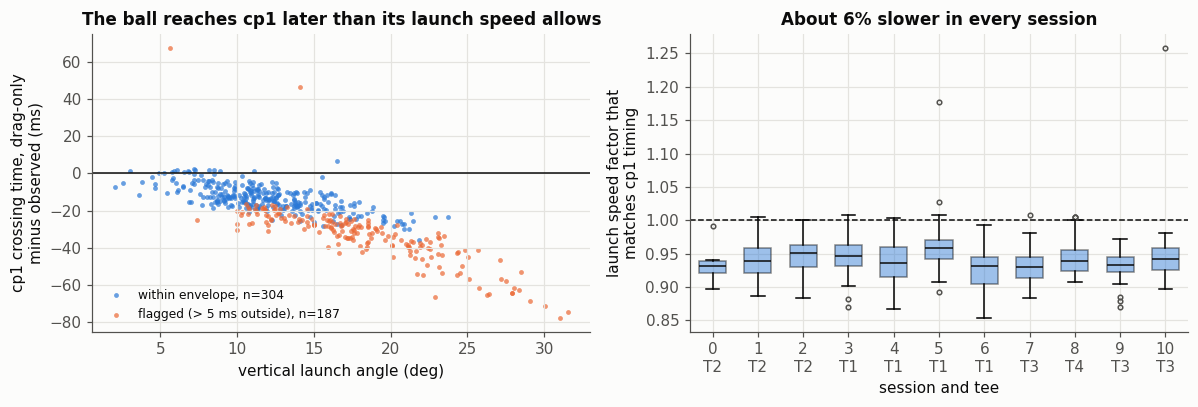

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
ax = axes[0]
for flag, color, label in [(False, BLUE, "within envelope"), (True, ORANGE, "flagged (> 5 ms outside)")]:
    sub = consistency[consistency["flag"] == flag]
    ax.scatter(sub["launch_angle"], 1000 * sub["dt_1"], s=10, color=color, alpha=0.7, lw=0, label=f"{label}, n={len(sub)}")
ax.axhline(0, color=INK, lw=1)
ax.set_xlabel("vertical launch angle (deg)")
ax.set_ylabel("cp1 crossing time, drag-only\nminus observed (ms)")
ax.set_title("The ball reaches cp1 later than its launch speed allows")
ax.legend(fontsize=8, loc="lower left")

ax = axes[1]
order = sorted(consistency["session"].unique())
data = [consistency.loc[consistency["session"] == s, "f1"] for s in order]
parts = ax.boxplot(data, positions=range(len(order)), widths=0.6, patch_artist=True, showfliers=True,
                   medianprops={"color": INK}, flierprops={"markersize": 3, "markeredgecolor": INK_2})
for box in parts["boxes"]:
    box.set_facecolor(BLUE)
    box.set_alpha(0.45)
ax.axhline(1, color=INK, lw=1, ls="--")
ax.set_xticks(range(len(order)), [f"{s}\n{consistency.loc[consistency['session'] == s, 'tee'].iloc[0]}" for s in order])
ax.set_xlabel("session and tee")
ax.set_ylabel("launch speed factor that\nmatches cp1 timing")
ax.set_title("About 6% slower in every session")
fig.tight_layout()
save(fig, "fig09_launch_consistency")
plt.show()

**Finding.** The disagreement is systematic, not a handful of bad shots. With drag-only textbook physics, the ball reaches cp1 a median 18 ms early and cp2 about 40 ms early, the same **6% to 7% of the elapsed time** at both. The launch speed factor that matches cp1 timing has a median of about 0.94 and agrees closely with the factor that matches cp2, which is what a launch speed that is a few percent too high would produce. A constant clock offset would instead give the same miss in milliseconds at both checkpoints.

About 38% of shots lie more than 5 ms outside even the extreme drag envelope at cp1, all on timing; no shot's lateral or height position is outside the envelope. The factor is lower (larger mismatch) for high-launch, high-spin shots, is present in every session and on every tee, and is flagged most often below 50 m/s. The simplest reading is that the radar's launch speed is biased high, most for high-spin shots, rather than that some sessions are faulty.

These shots are not dropped or corrected here. The fit below uses a robust loss, and the global coefficients will partly absorb the extra early deceleration, which should be kept in mind when reading them. A per-shot launch speed correction is a candidate for step 6.

## 3. Global fit

**Unknowns.** $c_{d0}, c_{d1}, c_{l0}, c_{l1}$ (and $\tau$ where stated) shared by all shots, plus one tilt per shot. Spin magnitude is the true `launch_spin_rate`.

**Residuals per shot** (simulated minus observed): position at each observed checkpoint time (12 numbers), apex position (3) and time (1), landing downrange and lateral position (2; simulated landing height is 0 by construction) and time (1).

**Scaling.** Each residual in group $g$ is divided by $\sigma_g \sqrt{n_g}$, so each of the five groups contributes about one unit of squared error per shot regardless of its units or how many numbers it has. $\sigma_g$ is 1.4826 times the median absolute residual of that group after a pilot fit at provisional scales; the final fit starts from the pilot solution.

**Robust loss.** soft_l1, applied per number with the count scaling undone, so every residual turns from quadratic to linear at 2 $\sigma_g$.

**Jacobian.** Each shot's residuals depend only on the globals and its own tilt, so with `jac_sparsity` a finite-difference Jacobian needs one batch simulation per global plus one for all tilts together.

In [5]:
def fit_everything():
    started = time.perf_counter()
    free = fit_globals(batch, fit_tau=True)
    fixed = OracleSpinPhysics().fit(train).fit_result
    profile = tau_profile(batch, free, [5.0, 10.0, 15.0, 25.0, 50.0, 100.0, 200.0])
    splits = leave_one_session_out_splits(train["session"])
    folds = physics_fold_results(train, splits, n_jobs=8)
    return {"free_tau": free, "full": fixed, "tau_profile": profile, "folds": folds,
            "wall_seconds": time.perf_counter() - started}

results = cached("physics_step5_results", fit_everything)
free, full, folds = results["free_tau"], results["full"], results["folds"]
print("tau free:", free.aero, f"cost {free.cost:.1f}")
print("\n".join(free.history))
print("\ntau fixed:", full.aero, f"cost {full.cost:.1f}, {full.nfev} residual evaluations, {full.seconds:.1f} s, status {full.status}")
print("\n".join(full.history))
print("\ntau profile (other globals refitted at each tau):")
print(results["tau_profile"])

tau free: Aero(cd0=0.20131696244102626, cd1=0.3514025607078432, cl0=0.44208289774658627, cl1=0.3767353643601745, tau=13.16594976294202) cost 1942.2
pilot: status 2, nfev 52, Aero(cd0=0.20319585544441734, cd1=0.36213843168963816, cl0=0.448831369960869, cl1=0.37502183579610876, tau=9.138604210280839)
scales: {'checkpoints': 0.5524424832816316, 'apex_pos': 1.3997265155992866, 'apex_t': 0.10774040568938853, 'landing_pos': 3.206307064340223, 'landing_t': 0.1795563734059026}
final: status 2, nfev 62, Aero(cd0=0.20131696244102626, cd1=0.3514025607078432, cl0=0.44208289774658627, cl1=0.3767353643601745, tau=13.16594976294202)

tau fixed: Aero(cd0=0.2019211073613457, cd1=0.33897145455918304, cl0=0.4344619361732133, cl1=0.3761286409098619, tau=25.0) cost 1959.3, 113 residual evaluations, 90.7 s, status 2
pilot: status 2, nfev 70, Aero(cd0=0.20450683796062277, cd1=0.33823446897656756, cl0=0.43316863711406733, cl1=0.37437167199071564, tau=25.0)
scales: {'checkpoints': 0.5458788365763425, 'apex_pos

### Is $\tau$ identifiable?

Across the profile the fit cost changes by well under 1% from $\tau$ = 10 s to 200 s, while $c_{d1}$ and $c_{l0}$ move to compensate. The flights last at most about 8 s, far shorter than any plausible decay time, so the data cannot pin $\tau$ down. The free fit's value is a weakly determined compromise, and $\tau$ is therefore **fixed at 25 s** (a typical literature value) for everything that follows.

In [6]:
fold_globals = pd.DataFrame([vars(f["fit"].aero) for f in folds])
fold_globals.index.name = "held-out session"
summary = pd.DataFrame({
    "textbook start": pd.Series(vars(TEXTBOOK)),
    "fit on all 491": pd.Series(vars(full.aero)),
    "fold mean": fold_globals.mean(),
    "fold sd": fold_globals.std(),
    "fold min": fold_globals.min(),
    "fold max": fold_globals.max(),
})
print(summary.drop(index="tau"))
print("\nper fold:")
print(fold_globals.drop(columns="tau"))
print("\nfit seconds per fold:", [round(f["fit"].seconds, 1) for f in folds])
print("scales used in the full fit (m or s):", {k: round(v, 3) for k, v in full.scales.items()})

     textbook start  fit on all 491  fold mean  fold sd  fold min  fold max
cd0            0.21           0.202      0.202    0.002     0.199     0.206
cd1            0.18           0.339      0.340    0.008     0.323     0.354
cl0            0.54           0.434      0.435    0.006     0.426     0.446
cl1            0.40           0.376      0.377    0.007     0.364     0.390

per fold:
                    cd0    cd1    cl0    cl1
held-out session                            
0                 0.202  0.341  0.436  0.378
1                 0.202  0.344  0.440  0.379
2                 0.204  0.337  0.434  0.371
3                 0.201  0.344  0.440  0.383
4                 0.203  0.333  0.428  0.369
5                 0.206  0.323  0.426  0.364
6                 0.200  0.354  0.446  0.390
7                 0.199  0.347  0.434  0.378
8                 0.201  0.335  0.429  0.373
9                 0.200  0.339  0.432  0.377
10                0.201  0.343  0.438  0.382

fit seconds per fold: [

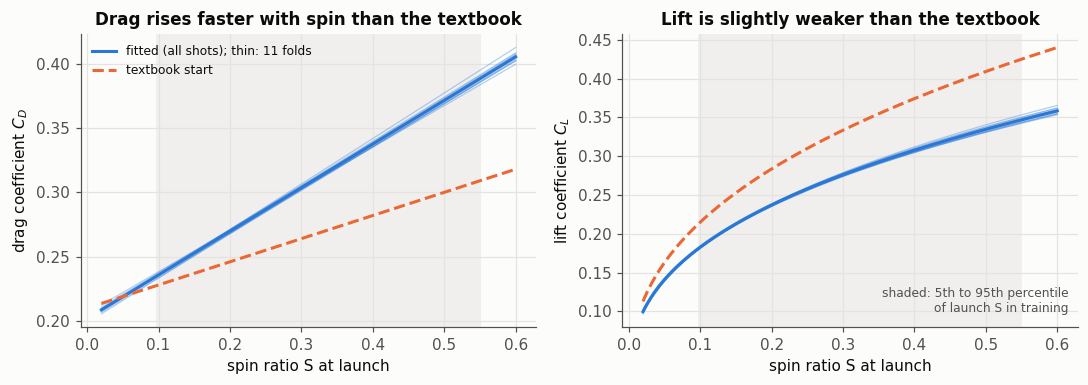

launch spin ratio: 5th pct 0.097, median 0.230, 95th pct 0.551


In [7]:
spin_ratio = np.linspace(0.02, 0.6, 200)
batch_ratio = batch.spin_rpm * 2 * np.pi / 60 * RADIUS / np.linalg.norm(batch.vel0, axis=1)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6), sharex=True)
for ax, name, textbook, fitted, folds_fn in [
    (axes[0], "drag coefficient $C_D$", TEXTBOOK.cd0 + TEXTBOOK.cd1 * spin_ratio,
     full.aero.cd0 + full.aero.cd1 * spin_ratio, lambda a: a.cd0 + a.cd1 * spin_ratio),
    (axes[1], "lift coefficient $C_L$", TEXTBOOK.cl0 * spin_ratio ** TEXTBOOK.cl1,
     full.aero.cl0 * spin_ratio ** full.aero.cl1, lambda a: a.cl0 * spin_ratio ** a.cl1),
]:
    for f in folds:
        ax.plot(spin_ratio, folds_fn(f["fit"].aero), color=BLUE, lw=0.8, alpha=0.35)
    ax.plot(spin_ratio, fitted, color=BLUE, lw=2, label="fitted (all shots); thin: 11 folds")
    ax.plot(spin_ratio, textbook, color=ORANGE, lw=2, ls="--", label="textbook start")
    ax.set_ylabel(name)
    ax.set_xlabel("spin ratio S at launch")
    lo, hi = np.percentile(batch_ratio, [5, 95])
    ax.axvspan(lo, hi, color=INK_2, alpha=0.07, lw=0)
axes[0].legend(fontsize=8, loc="upper left")
axes[0].set_title("Drag rises faster with spin than the textbook")
axes[1].set_title("Lift is slightly weaker than the textbook")
axes[1].annotate("shaded: 5th to 95th percentile\nof launch S in training", (0.98, 0.04), xycoords="axes fraction",
                 ha="right", va="bottom", fontsize=8, color=INK_2)
fig.tight_layout()
save(fig, "fig10_fitted_coefficients")
plt.show()
print(f"launch spin ratio: 5th pct {lo:.3f}, median {np.median(batch_ratio):.3f}, 95th pct {hi:.3f}")

## 4. Honest evaluation: leave one session out

For each of the 11 sessions, the globals are fitted on the other 10 sessions. Each held-out shot then gets a tilt fitted **from its checkpoints only** (no apex or landing targets), keeps its true spin magnitude, and is simulated to apex and landing. The harness scores position and time components only: the composite below uses the step 3 weights with spin set to zero (`WEIGHTS_WITHOUT_SPIN`), for physics and LightGBM alike, so the two are directly comparable. LightGBM is the step 4 baseline without the session feature, on the same folds.

In [8]:
splits = leave_one_session_out_splits(train["session"])
shares = speed_band(test).value_counts(normalize=True).to_dict()
physics_cv = cross_validate(replay_fit_predict(folds), train, splits, train["session"], shares,
                            "physics (oracle spin)", WEIGHTS_WITHOUT_SPIN)
lgbm_cv = cross_validate(lgbm_fit_predict(use_session=False), train, splits, train["session"], shares,
                         "LightGBM", WEIGHTS_WITHOUT_SPIN)

show = ["strategy", "n", "composite"] + [c for c in COMPONENTS if c != "spin"] + [f"{c}_scaled" for c in COMPONENTS if c != "spin"]
table = pd.concat([physics_cv.report(), lgbm_cv.report()])[show].rename(columns={"composite": "composite_no_spin"})
print(table)
print()
print(pd.DataFrame({"physics (oracle spin)": physics_cv.test_mix_spread(), "LightGBM": lgbm_cv.test_mix_spread()}).T)

                             strategy      n  composite_no_spin  landing_pos  apex_pos  apex_t  landing_t  landing_pos_scaled  apex_pos_scaled  apex_t_scaled  landing_t_scaled
overall         physics (oracle spin)  491.0              0.167        7.929     3.914   0.108      0.213               0.188            0.125          0.231             0.249
test speed mix  physics (oracle spin)  491.0              0.176        8.466     4.227   0.109      0.224               0.201            0.135          0.235             0.262
band <50 m/s    physics (oracle spin)  165.0              0.112        5.260     2.347   0.075      0.158               0.125            0.075          0.162             0.184
band 50-70 m/s  physics (oracle spin)  289.0              0.186        8.824     4.442   0.123      0.232               0.210            0.142          0.264             0.271
band >=70 m/s   physics (oracle spin)   37.0              0.257       12.839     6.782   0.130      0.314               

In [9]:
paired = pd.DataFrame({
    column: compare_results(physics_cv, lgbm_cv, column)
    for column in ["composite", "landing_pos", "apex_pos", "apex_t", "landing_t"]
}).T
print("physics minus LightGBM, per held-out session (negative = physics better):")
print(paired)
per_session = pd.concat({"physics": physics_cv.by_session()[["n", "composite", "landing_pos", "apex_pos", "landing_t"]],
                         "LightGBM": lgbm_cv.by_session()[["composite", "landing_pos", "apex_pos", "landing_t"]]}, axis=1)
print(per_session)

physics minus LightGBM, per held-out session (negative = physics better):
             mean_diff  sd_diff  se_diff      t  n_folds  a_better
composite        0.040    0.037    0.011  3.566     11.0       1.0
landing_pos      2.273    2.451    0.739  3.075     11.0       2.0
apex_pos         0.625    0.841    0.253  2.466     11.0       1.0
apex_t           0.019    0.021    0.006  2.928     11.0       2.0
landing_t        0.056    0.055    0.017  3.365     11.0       1.0
        physics                                           LightGBM                               
              n composite landing_pos apex_pos landing_t composite landing_pos apex_pos landing_t
session                                                                                          
0          12.0     0.137       4.742    2.661     0.264     0.109       4.238    1.756     0.218
1          45.0     0.204       9.811    3.871     0.326     0.118       5.964    2.533     0.137
2          61.0     0.136       5.

In [10]:
# Sensitivity of simulated carry to a 1% launch speed error, at the fitted coefficients.
tilt_full = full.tilt.to_numpy()
base = simulate(batch.vel0, batch.spin_rpm, tilt_full, full.aero)
faster = simulate(batch.vel0 * 1.01, batch.spin_rpm, tilt_full, full.aero)
carry = pd.Series(base.landing_pos[:, 0])
change = pd.Series(faster.landing_pos[:, 0] - base.landing_pos[:, 0])
print("median change in level carry for +1% launch speed (m), by simulated carry:")
print(change.groupby(pd.cut(carry, [0, 120, 180, 300])).agg(["size", "median"]))

median change in level carry for +1% launch speed (m), by simulated carry:
            size  median
(0, 120]     107   1.542
(120, 180]   208   2.064
(180, 300]   176   2.645


### Reading the oracle-spin ceiling

Even with the true spin, the physics model is **worse than LightGBM on every position and time component** out of fold, and the paired comparison says this is not session luck: it loses in 10 of 11 held-out sessions on the spin-free composite. Landing error is about 2 m larger on average, and landing time is the weakest component (scaled 0.25 against 0.19).

Where physics wins: apex time for fast shots (70 m/s and above), where it extrapolates better than the trees, and sessions 10 and, for landing position, 2. Where it loses most: landing position for fast shots and the held-out tee T4 (session 8). A global coefficient set cannot absorb per-shot launch errors. The launch-consistency check shows launch speed biased high by a few percent, with the bias varying between shots, and a 1% speed error alone moves the simulated carry by about 2.6 m for shots beyond 180 m (cell above). The physics carry inherits all of that, while LightGBM leans on checkpoint-derived speeds that are not biased. The obvious next step (step 6) is to fit each shot's initial speed, and possibly direction, along with its spin from the checkpoints, instead of trusting the launch vector.

## 5. Diagnostics

In [11]:
# Pooled out-of-fold predictions, in the shot frame.
oof = pd.concat([f["predictions"] for f in folds]).loc[train.index]
oof_frame = add_shot_frame(train[[c for c in train.columns if c not in TARGET_COLS]].join(oof))
residuals = pd.DataFrame({
    "landing downrange (m)": oof_frame["landing_d"] - frame["landing_d"],
    "landing lateral (m)": oof_frame["landing_l"] - frame["landing_l"],
    "apex height (m)": oof_frame["apex_h"] - frame["apex_h"],
    "landing time (s)": oof["landing_t"] - train["landing_t"],
}, index=train.index)
drivers = pd.DataFrame({
    "ball speed (m/s)": ball_speed(train),
    "launch angle (deg)": consistency["launch_angle"],
    "launch spin (rpm)": train["launch_spin_rate"],
}, index=train.index)
print("out-of-fold residuals (predicted minus true):")
print(residuals.describe().T)
print("\ncorrelation of residuals with launch conditions:")
print(pd.DataFrame({d: residuals.corrwith(drivers[d]) for d in drivers}).round(3))

out-of-fold residuals (predicted minus true):
                       count   mean    std     min    25%    50%    75%     max
landing downrange (m)  491.0  0.422  7.687 -34.109 -4.523  0.068  5.963  22.158
landing lateral (m)    491.0 -0.447  6.153 -57.766 -2.951 -0.259  2.419  24.198
apex height (m)        491.0  0.265  2.231 -13.945 -0.760  0.266  1.302   7.878
landing time (s)       491.0  0.090  0.286  -1.766 -0.070  0.083  0.223   1.030

correlation of residuals with launch conditions:
                       ball speed (m/s)  launch angle (deg)  launch spin (rpm)
landing downrange (m)             0.135              -0.176             -0.229
landing lateral (m)               0.023              -0.026              0.005
apex height (m)                   0.251              -0.163             -0.164
landing time (s)                  0.101               0.004             -0.018


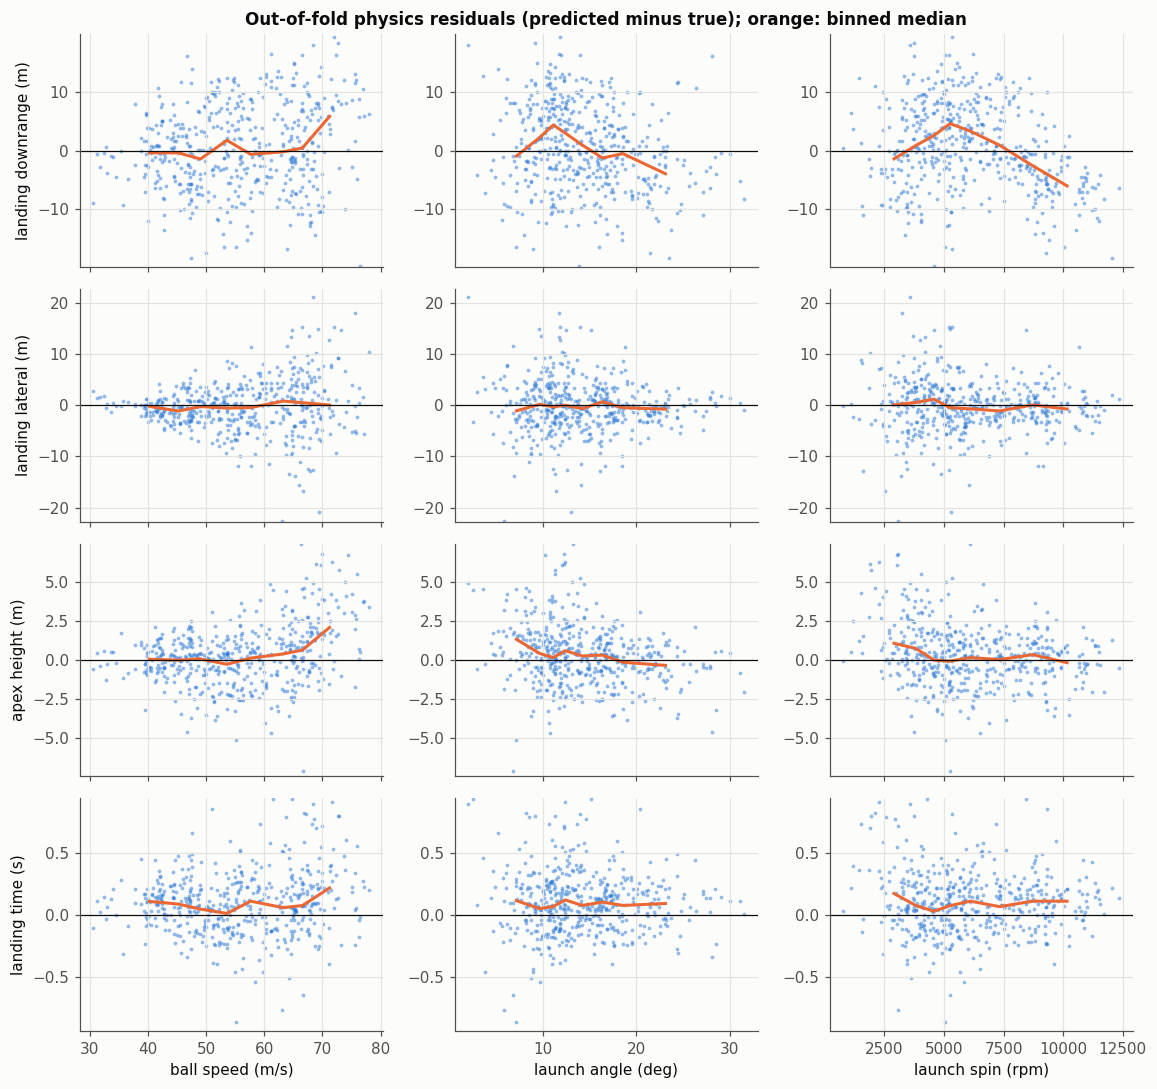

In [12]:
fig, axes = plt.subplots(4, 3, figsize=(10.5, 10), sharex="col")
for i, res_name in enumerate(residuals):
    for j, drv_name in enumerate(drivers):
        ax = axes[i, j]
        x, y = drivers[drv_name], residuals[res_name]
        ax.scatter(x, y, s=6, color=BLUE, alpha=0.5, lw=0)
        bins = np.quantile(x, np.linspace(0, 1, 9))
        centres = [(x[(x >= a) & (x <= b)]).median() for a, b in zip(bins[:-1], bins[1:])]
        medians = [(y[(x >= a) & (x <= b)]).median() for a, b in zip(bins[:-1], bins[1:])]
        ax.plot(centres, medians, color=ORANGE, lw=2)
        ax.axhline(0, color=INK, lw=0.8)
        lim = np.nanpercentile(np.abs(y), 99)
        ax.set_ylim(-lim, lim)
        if j == 0:
            ax.set_ylabel(res_name)
        if i == 3:
            ax.set_xlabel(drv_name)
axes[0, 1].set_title("Out-of-fold physics residuals (predicted minus true); orange: binned median")
fig.tight_layout()
save(fig, "fig11_physics_residuals")
plt.show()

The residuals are not flat. Landing downrange error falls with spin: mid-spin shots (about 5000 rpm) land slightly beyond the truth and high-spin shots (above 8000 rpm) short of it. So the linear drag and power-law lift in spin ratio do not capture how the real coefficients change across clubs. Apex height is over-predicted for the fastest shots, and landing time is on average slightly late at every speed. Lateral residuals show no trend, but they have heavy tails.

        tee  shots  landing downrange (m) mean  landing downrange (m) t  landing lateral (m) mean  landing lateral (m) t
session                                                                                                                 
0        T2     12                      -0.389                   -0.247                    -0.696                 -0.974
1        T2     45                      -5.704                   -5.433                    -3.271                 -2.624
2        T2     61                      -1.770                   -2.908                    -2.466                 -2.474
3        T1     26                      -5.148                   -4.133                    -3.933                 -2.769
4        T1     21                       6.104                    6.350                     0.276                  0.216
5        T1     88                       1.793                    2.693                     1.153                  2.102
6        T1     72              

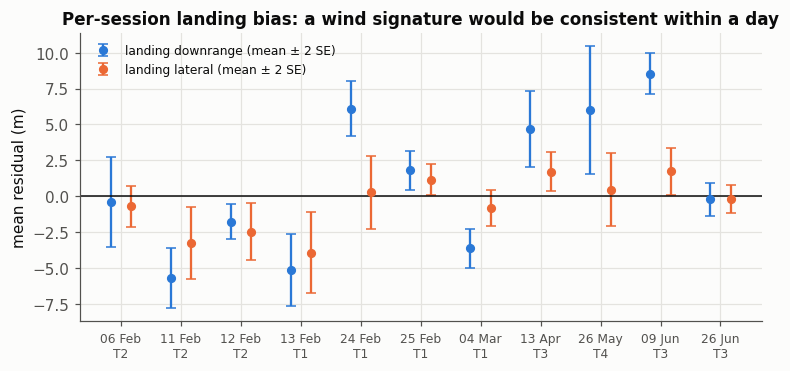

corr(session mean downrange residual, session median launch speed factor): -0.27


In [13]:
by_session = residuals.groupby(train["session"]).agg(["mean", "sem", "size"])
wind = pd.DataFrame({
    "tee": assign_tees(train).groupby(train["session"]).first(),
    "shots": by_session[("landing downrange (m)", "size")],
})
for name in ["landing downrange (m)", "landing lateral (m)"]:
    wind[f"{name} mean"] = by_session[(name, "mean")]
    wind[f"{name} t"] = by_session[(name, "mean")] / by_session[(name, "sem")]
print(wind)
print("\nsessions with |t| > 3: downrange",
      int((wind["landing downrange (m) t"].abs() > 3).sum()), ", lateral", int((wind["landing lateral (m) t"].abs() > 3).sum()))

local = pd.to_datetime(train["launch_time"], unit="s", utc=True).dt.tz_convert("Africa/Johannesburg")
dates = local.groupby(train["session"]).first().dt.strftime("%d %b")
fig, ax = plt.subplots(figsize=(8, 3.4))
x = np.arange(len(wind))
for offset, name, color in [(-0.17, "landing downrange (m)", BLUE), (0.17, "landing lateral (m)", ORANGE)]:
    mean = by_session[(name, "mean")]
    sem = by_session[(name, "sem")]
    ax.errorbar(x + offset, mean, yerr=2 * sem, fmt="o", color=color, ms=5, capsize=3, lw=1.5,
                label=f"{name.split(' (')[0]} (mean ± 2 SE)")
ax.axhline(0, color=INK, lw=1)
ax.set_xticks(x, [f"{d}\n{t}" for d, t in zip(dates, wind["tee"])], fontsize=8)
ax.set_ylabel("mean residual (m)")
ax.set_title("Per-session landing bias: a wind signature would be consistent within a day")
ax.legend(fontsize=8, loc="upper left")
save(fig, "fig12_session_bias")
plt.show()

session_f1 = consistency.groupby("session")["f1"].median()
print("corr(session mean downrange residual, session median launch speed factor):",
      round(float(np.corrcoef(wind["landing downrange (m) mean"], session_f1)[0, 1]), 3))

**Wind?** Six of the eleven sessions have a mean downrange residual more than three standard errors from zero, ranging from about -6 m to +9 m, with signs that vary between days, including between sessions from the same tee. Lateral means are smaller and none passes three standard errors. A consistent within-day downrange bias is what a head- or tailwind would produce, so wind is a plausible explanation. It is not the only one: each session is also one player, one set of clubs and one launch-speed bias pattern, and those are confounded with the day. The session biases are only weakly related to the sessions' launch-speed factors (correlation about -0.27, printed above). This is recorded, not modelled; a per-session correction is possible later because every test session also appears in train.

In [14]:
# Checkpoint fit quality: training shots in the full fit (tilt fitted with apex
# and landing), and held-out shots (tilt fitted from checkpoints only).
raw_full = _residual_blocks(batch, full.aero, full.tilt.to_numpy(), True)
held_out = []
for f, (_, val_idx) in zip(folds, splits):
    sub = batch.subset(val_idx)
    held_out.append(_residual_blocks(sub, f["fit"].aero, f["val_tilt"].to_numpy(), False))
held_out = np.vstack(held_out)
axes_names = ["downrange", "lateral", "height"]
rms = pd.DataFrame(
    {f"cp{k + 1}": [np.sqrt(np.mean(raw_full[:, 3 * k + a] ** 2)) for a in range(3)]
                   + [np.sqrt(np.mean(held_out[:, 3 * k + a] ** 2)) for a in range(3)] for k in range(4)},
    index=[f"full fit, {a}" for a in axes_names] + [f"held out, {a}" for a in axes_names],
)
print("checkpoint RMS residual (m):")
print(rms)
print("\noverall RMS over all 12 numbers: full fit", round(float(np.sqrt(np.mean(raw_full[:, :12] ** 2))), 3),
      "m, held out", round(float(np.sqrt(np.mean(held_out ** 2))), 3), "m")
print("median |residual| per group, full fit:", {k: round(v, 3) for k, v in robust_group_scales(raw_full).items()})

checkpoint RMS residual (m):
                       cp1    cp2    cp3    cp4
full fit, downrange  0.795  1.147  1.310  1.558
full fit, lateral    0.133  0.271  0.440  0.632
full fit, height     0.269  0.513  0.762  1.023
held out, downrange  0.793  1.143  1.314  1.594
held out, lateral    0.104  0.140  0.131  0.175
held out, height     0.270  0.519  0.780  1.064

overall RMS over all 12 numbers: full fit 0.853 m, held out 0.835 m
median |residual| per group, full fit: {'checkpoints': 0.558, 'apex_pos': 1.242, 'apex_t': 0.108, 'landing_pos': 3.042, 'landing_t': 0.208}


Checkpoint residuals are dominated by the **downrange** direction (0.8 m at cp1 growing to 1.6 m at cp4). That is the launch-speed bias from section 2 showing up as timing error. Lateral residuals are small when the tilt is fitted to checkpoints only (held out), and larger in the full fit, where each tilt also has to serve apex and landing lateral position. So one fixed spin axis per shot cannot fit early and late curvature equally well.

### What exactly is `landing_t`?

`01_eda.ipynb` found every `landing_t` and `apex_t` on a 0.01 s grid and `landing_z - launch_z` spread over about ±0.2 m. Two tests: which hundredths the times fall on, and how far the recorded landing sits from the true level crossing. For the second, if the recorded landing is at time $t_r$ and the true crossing at $t_c$, the recorded height offset is about $v_h (t_r - t_c)$, so

$$\delta = \frac{\text{landing\_z} - \text{launch\_z}}{v_h}$$

with $v_h$ the simulated vertical speed at landing (negative). The model's own landing-time error is far larger than a few milliseconds, but it cancels here because only the height offset and the descent speed are used. A nearest-sample rule on a 100 Hz grid would give $\delta$ within ±5 ms; a first-sample-below rule would give [0, 10) ms.

last digit of time in hundredths    0   1   2   3   4    5   6   7    8   9
apex_t                            106   0  94   0  93    0  95   0  103   0
landing_t                           0  93   0  98   0  115   0  91    0  94
apex_t: share on odd hundredths = 0.000
landing_t: share on odd hundredths = 1.000

descent speed at landing (m/s): {'count': 491.0, 'mean': -15.39, 'std': 2.84, 'min': -22.28, '25%': -17.24, '50%': -15.69, '75%': -13.8, 'max': -5.5}
implied offset delta (ms): {'count': 491.0, 'mean': -0.28, 'std': 5.8, 'min': -11.94, '1%': -10.88, '5%': -9.12, '50%': -0.33, '95%': 9.01, '99%': 10.64, 'max': 12.47}
share within ±5 ms: 0.515; within ±10 ms: 0.961; within ±11 ms: 0.986; share in [0, 10) ms: 0.468
sd of a uniform distribution on ±10 ms: 5.77 ms



in-sample simulated continuous landing time minus recorded (ms): {'count': 491.0, 'mean': 69.7, 'std': 252.6, 'min': -1770.2, '25%': -59.9, '50%': 62.4, '75%': 189.3, 'max': 1006.2}


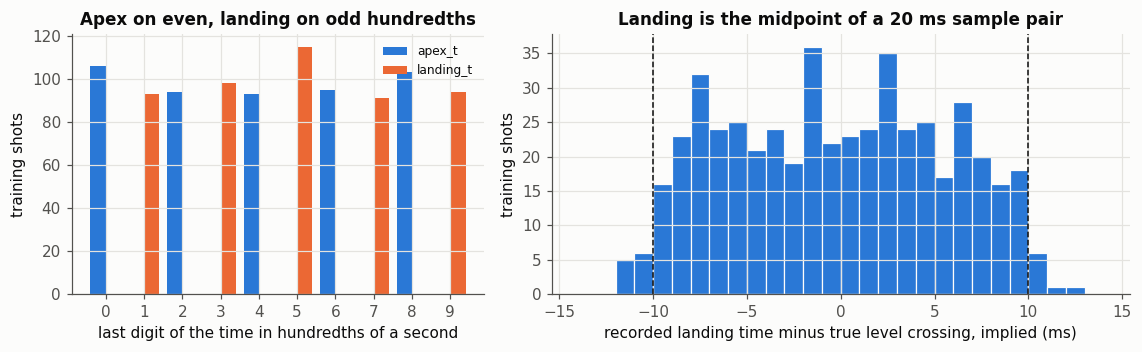

In [15]:
hundredths = pd.DataFrame({
    col: np.bincount(np.round(train[col] * 100).astype(int) % 10, minlength=10) for col in ["apex_t", "landing_t"]
})
hundredths.index.name = "last digit of time in hundredths"
print(hundredths.T)
for col in ["apex_t", "landing_t"]:
    odd = (np.round(train[col] * 100).astype(int) % 2 == 1).mean()
    print(f"{col}: share on odd hundredths = {odd:.3f}")

summary_full = simulate(batch.vel0, batch.spin_rpm, full.tilt.to_numpy(), full.aero, batch.cp_t)
landing_vh = summary_full.landing_vel[:, 2]
offset_h = (train["landing_z"] - train["launch_z"]).to_numpy()
delta_ms = 1000 * offset_h / landing_vh
print("\ndescent speed at landing (m/s):", pd.Series(landing_vh).describe().round(2).to_dict())
print("implied offset delta (ms):", pd.Series(delta_ms).describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).round(2).to_dict())
print(f"share within ±5 ms: {np.mean(np.abs(delta_ms) <= 5):.3f}; within ±10 ms: {np.mean(np.abs(delta_ms) <= 10):.3f}; "
      f"within ±11 ms: {np.mean(np.abs(delta_ms) <= 11):.3f}; share in [0, 10) ms: {np.mean((delta_ms >= 0) & (delta_ms < 10)):.3f}")
print(f"sd of a uniform distribution on ±10 ms: {20 / np.sqrt(12):.2f} ms")

sim_full = predict_shot_frame(batch, full.aero, full.tilt.to_numpy())
print("\nin-sample simulated continuous landing time minus recorded (ms):",
      (1000 * (sim_full["landing_t"] - train["landing_t"])).describe().round(1).to_dict())

fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.3), width_ratios=[1, 1.4])
ax = axes[0]
digits = np.arange(10)
ax.bar(digits - 0.2, hundredths["apex_t"], width=0.4, color=BLUE, label="apex_t")
ax.bar(digits + 0.2, hundredths["landing_t"], width=0.4, color=ORANGE, label="landing_t")
ax.set_xticks(digits)
ax.set_xlabel("last digit of the time in hundredths of a second")
ax.set_ylabel("training shots")
ax.set_title("Apex on even, landing on odd hundredths")
ax.legend(fontsize=8)
ax = axes[1]
ax.hist(delta_ms, bins=np.arange(-14, 14.5, 1), color=BLUE, edgecolor=SURFACE, lw=0.8)
for edge in (-10, 10):
    ax.axvline(edge, color=INK, lw=1, ls="--")
ax.set_xlabel("recorded landing time minus true level crossing, implied (ms)")
ax.set_ylabel("training shots")
ax.set_title("Landing is the midpoint of a 20 ms sample pair")
fig.tight_layout()
save(fig, "fig13_landing_sample")
plt.show()

**Finding.** Every `apex_t` is an even number of hundredths and every `landing_t` an odd number. The radar evidently samples every 20 ms (50 Hz) from launch: the apex is reported at a sample, and the level landing at the **midpoint of the two samples that bracket the crossing**. The implied offset $\delta$ is spread almost evenly over ±10 ms with a standard deviation matching a uniform distribution on that interval, as that rule predicts. It is not the nearest sample on a 100 Hz grid (only about half the shots are within ±5 ms), nor the first sample below launch height (the offset takes both signs).

Consequences: `landing_z - launch_z` is the descent speed times that offset (about ±0.15 m at 15 m/s), so predicting `landing_z = launch_z` is right. The quantisation adds irreducible errors of up to 10 ms in landing time and about 0.1 to 0.2 m in landing position, both far below the model's current errors. Rounding predicted times to the grid would gain almost nothing until timing errors approach a few hundredths of a second.

## 6. Treating the checkpoints as the truth: speed factor and inverse solve

The oracle-spin model lost to LightGBM, and the launch speed runs about 6% high against the checkpoints. From here each shot gets a **speed factor** $k$ (initial velocity $= k \times$ given launch velocity, direction unchanged), and the checkpoints, not the launch vector, decide the shot's state.

**Refit.** The global fit of section 3 is repeated with $k$ as a second per-shot unknown (true spin, $\tau$ = 25 s, same scaling and robust loss). `inrange.hybrid.run_all_artefacts` does this for every leave-one-session-out fold, every within-session repeat and all training rows, in parallel, and caches the result.

**Inverse solve** (`inrange.inverse.solve_states`). With the globals fixed, spin, tilt and $k$ are fitted per shot from the 12 checkpoint residuals only, with no targets, so the same solve works on test shots. Bounds: spin within the training range (775 to 12,349 rpm), $k$ within 0.90 to 1.10. The full-data refit puts the 0.5th to 99.5th percentiles of $k$ at about 0.925 to 1.085, and 0.90 to 1.10 covers that with a margin.

In [16]:
from inrange.hybrid import run_all_artefacts
from inrange.inverse import solve_states

step6 = cached("step6_artefacts", lambda: run_all_artefacts(train, test))
full6 = step6["full"]
loso6 = step6["leave_one_session_out"]
print(f"all 22 physics artefacts: {step6['seconds']:.0f} s wall time on 8 workers")
print(f"full refit with speed factor: {full6.fit.seconds:.1f} s, {full6.fit.nfev} residual evaluations, status {full6.fit.status}")
print("\n".join(full6.fit.history))

globals6 = pd.DataFrame([vars(a.fit.aero) for a in loso6]).drop(columns="tau")
print(pd.DataFrame({
    "textbook": pd.Series(vars(TEXTBOOK)).drop("tau"),
    "step 5 (no k)": pd.Series(vars(full.aero)).drop("tau"),
    "step 6 (with k)": pd.Series(vars(full6.fit.aero)).drop("tau"),
    "step 6 fold mean": globals6.mean(),
    "step 6 fold sd": globals6.std(),
}))
print("\nresidual scales (m or s): step 5", {k: round(v, 3) for k, v in full.scales.items()})
print("                          step 6", {k: round(v, 3) for k, v in full6.fit.scales.items()})

all 22 physics artefacts: 983 s wall time on 8 workers
full refit with speed factor: 60.8 s, 30 residual evaluations, status 2
pilot: status 2, nfev 21, Aero(cd0=0.18344729439096746, cd1=0.326490149048958, cl0=0.43872616264557357, cl1=0.38870286870964976, tau=25.0)
scales: {'checkpoints': 0.3983546593478144, 'apex_pos': 1.1212534318453018, 'apex_t': 0.0918355078131035, 'landing_pos': 2.547689995623205, 'landing_t': 0.13361075479551343}
final: status 2, nfev 9, Aero(cd0=0.18418904805235392, cd1=0.3284866340450663, cl0=0.440929329869113, cl1=0.3910323677397356, tau=25.0)
     textbook  step 5 (no k)  step 6 (with k)  step 6 fold mean  step 6 fold sd
cd0      0.21          0.202            0.184             0.184           0.002
cd1      0.18          0.339            0.328             0.329           0.008
cl0      0.54          0.434            0.441             0.441           0.006
cl1      0.40          0.376            0.391             0.391           0.007

residual scales (m or s

In [17]:
k = full6.fit.speed
print("speed factor k (full refit):")
print(k.describe(percentiles=[0.005, 0.05, 0.25, 0.5, 0.75, 0.95, 0.995]).round(4))
print(f"shots with k < 1: {(k < 1).mean():.3f}")
for name, values in [("launch angle", consistency["launch_angle"]), ("launch spin", train["launch_spin_rate"]),
                     ("ball speed", consistency["ball_speed"]), ("step 5 drag-only factor f1", consistency["f1"])]:
    print(f"corr(k, {name}) = {np.corrcoef(k, values)[0, 1]:.3f}")
print("median k by session:", k.groupby(train["session"]).median().round(3).to_dict())

speed factor k (full refit):
count    491.000
mean       0.975
std        0.022
min        0.914
0.5%       0.925
5%         0.946
25%        0.963
50%        0.973
75%        0.984
95%        1.004
99.5%      1.085
max        1.178
Name: speed, dtype: float64
shots with k < 1: 0.925
corr(k, launch angle) = -0.004
corr(k, launch spin) = 0.031
corr(k, ball speed) = -0.214
corr(k, step 5 drag-only factor f1) = 0.450
median k by session: {0: 0.97, 1: 0.969, 2: 0.981, 3: 0.966, 4: 0.978, 5: 0.978, 6: 0.974, 7: 0.964, 8: 0.967, 9: 0.968, 10: 0.976}


### Is spin identifiable from the checkpoints?

In [18]:
no_prior = solve_states(batch, full6.fit.aero, full6.fit.scales)
states_np = no_prior.states
print(f"no prior, all training shots, full-data globals: {no_prior.seconds:.1f} s, {no_prior.nfev} evaluations")
print(f"  spin MAE {np.abs(states_np['spin'] - train['launch_spin_rate']).mean():.0f} rpm, "
      f"corr(fitted, true) {np.corrcoef(states_np['spin'], train['launch_spin_rate'])[0, 1]:.3f}")
print(f"  shots at a spin bound: {int(((states_np['spin'] <= 776) | (states_np['spin'] >= 12348)).sum())}")
print("  local corr(spin, k):", states_np["corr_spin_speed"].describe(percentiles=[0.25, 0.5, 0.75]).round(3).to_dict())
print("  local sd(spin) (rpm):", states_np["sd_spin"].describe(percentiles=[0.25, 0.5, 0.75]).round(0).to_dict())
print(f"  across shots: corr(spin error, k minus refit k) = "
      f"{np.corrcoef(states_np['spin'] - train['launch_spin_rate'], states_np['speed'] - k)[0, 1]:.3f}")

no prior, all training shots, full-data globals: 26.3 s, 48 evaluations
  spin MAE 1361 rpm, corr(fitted, true) 0.829
  shots at a spin bound: 13
  local corr(spin, k): {'count': 491.0, 'mean': 0.486, 'std': 0.154, 'min': -0.628, '25%': 0.38, '50%': 0.525, '75%': 0.604, 'max': 0.867}
  local sd(spin) (rpm): {'count': 491.0, 'mean': 482.0, 'std': 132.0, 'min': 156.0, '25%': 395.0, '50%': 477.0, '75%': 562.0, 'max': 962.0}
  across shots: corr(spin error, k minus refit k) = 0.228


Without help, the checkpoints pin spin down poorly: the fit is worse than LightGBM's spin prediction, and spin and $k$ are positively correlated within most shots (more spin means more drag, which a higher launch speed can offset). A **weak prior** is therefore added: one extra residual per shot, (spin minus the LightGBM spin prediction) divided by the standard deviation of LightGBM's own out-of-fold spin error. That prediction is inner five-fold out-of-fold for training rows and from a model fitted on all training rows for validation and test rows. The prior's strength is thus set by how wrong LightGBM usually is, not tuned.

In [19]:
rows = []
for strategy in ["leave_one_session_out", "within_session"]:
    for art in step6[strategy]:
        truth = train.loc[art.val_states.index, "launch_spin_rate"]
        rows.append({
            "strategy": strategy,
            "shots": len(truth),
            "prior_sd": art.prior_sd,
            "fitted_abs_err": np.abs(art.val_states["spin"] - truth).sum(),
            "prior_abs_err": np.abs(art.val_states["prior"] - truth).sum(),
            "k_abs_diff": np.abs(art.val_states["speed"] - k.loc[truth.index]).sum(),
            "corr_spin_speed": art.val_states["corr_spin_speed"].median(),
        })
spin_check = pd.DataFrame(rows).groupby("strategy").agg(
    shots=("shots", "sum"), prior_sd_mean=("prior_sd", "mean"), fitted=("fitted_abs_err", "sum"),
    prior=("prior_abs_err", "sum"), k=("k_abs_diff", "sum"), corr=("corr_spin_speed", "median"))
spin_check["fitted spin MAE (rpm)"] = spin_check.pop("fitted") / spin_check["shots"]
spin_check["LightGBM prior MAE (rpm)"] = spin_check.pop("prior") / spin_check["shots"]
spin_check["|k - refit k| mean"] = spin_check.pop("k") / spin_check["shots"]
spin_check = spin_check.rename(columns={"corr": "median local corr(spin, k)"})
print(spin_check.round(3))
print("\nstep 4 LightGBM spin MAE for reference: 1051 rpm leave-one-session-out, 876 rpm within-session")

oof6 = pd.concat([a.val_states for a in loso6]).loc[train.index]
print(f"\nLOSO: corr(held-out k, refit k) = {np.corrcoef(oof6['speed'], k)[0, 1]:.3f}; "
      f"shots at k bound: {int(((oof6['speed'] <= 0.9001) | (oof6['speed'] >= 1.0999)).sum())}; "
      f"median checkpoint RMS {oof6['cp_rms'].median():.3f} m")

                       shots  prior_sd_mean  median local corr(spin, k)  fitted spin MAE (rpm)  LightGBM prior MAE (rpm)  |k - refit k| mean
strategy                                                                                                                                    
leave_one_session_out    491       1080.715                       0.332                983.094                  1050.936               0.012
within_session          2570       1176.531                       0.359                870.836                   876.450               0.012

step 4 LightGBM spin MAE for reference: 1051 rpm leave-one-session-out, 876 rpm within-session

LOSO: corr(held-out k, refit k) = 0.664; shots at k bound: 2; median checkpoint RMS 0.298 m


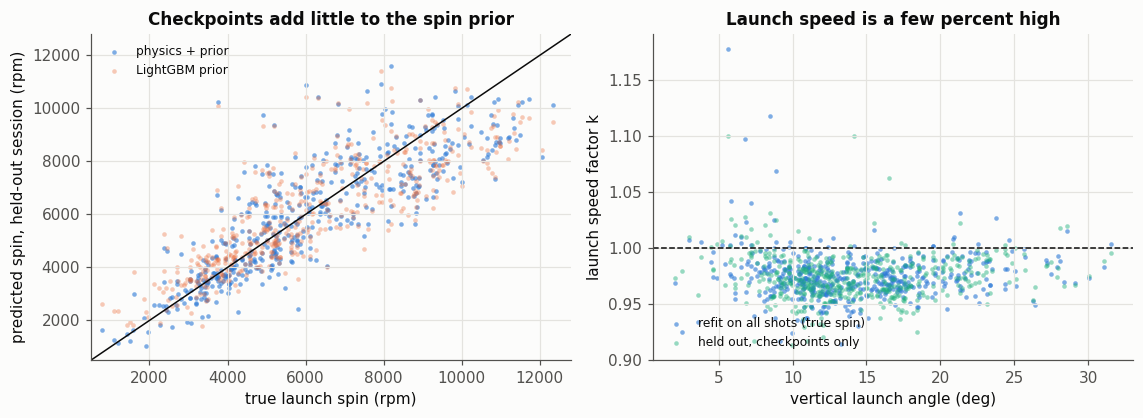

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.9))
ax = axes[0]
ax.scatter(train["launch_spin_rate"], oof6["spin"], s=9, color=BLUE, alpha=0.6, lw=0, label="physics + prior")
ax.scatter(train["launch_spin_rate"], oof6["prior"], s=9, color=ORANGE, alpha=0.35, lw=0, label="LightGBM prior")
lims = [500, 12800]
ax.plot(lims, lims, color=INK, lw=1)
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel("true launch spin (rpm)")
ax.set_ylabel("predicted spin, held-out session (rpm)")
ax.set_title("Checkpoints add little to the spin prior")
ax.legend(fontsize=8, loc="upper left")

ax = axes[1]
ax.scatter(consistency["launch_angle"], k, s=9, color=BLUE, alpha=0.6, lw=0, label="refit on all shots (true spin)")
ax.scatter(consistency["launch_angle"], oof6["speed"], s=9, color=AQUA, alpha=0.45, lw=0, label="held out, checkpoints only")
ax.axhline(1, color=INK, lw=1, ls="--")
ax.set_xlabel("vertical launch angle (deg)")
ax.set_ylabel("launch speed factor k")
ax.set_title("Launch speed is a few percent high")
ax.legend(fontsize=8, loc="lower left")
fig.tight_layout()
save(fig, "fig14_inverse_solve")
plt.show()

**Findings (section 6).**

* **Globals.** With a per-shot speed factor, $c_{d0}$ drops from 0.202 to 0.184, while $c_{d1}$, $c_{l0}$ and $c_{l1}$ barely move. They are stable across folds (standard deviation at most 0.008). Every group's typical residual shrinks: checkpoints 0.55 to 0.40 m, landing 3.2 to 2.5 m, landing time 0.19 to 0.13 s.
* **Speed factor.** The median $k$ is 0.973, and 92.5% of shots have $k < 1$: the radar launch speed is about 2.7% high once drag is fitted properly. $k$ no longer depends on launch angle or spin (correlations near 0) and only weakly on ball speed (-0.21), so the angle and spin dependence of the step 5 drag-only factor was mostly the textbook drag being wrong. Session medians range from 0.964 to 0.981.
* **Identifiability.** From the checkpoints alone, spin is poorly determined (MAE 1361 rpm even with in-sample globals, local uncertainty about 480 rpm) and trades off against $k$ (median local correlation 0.53). With the LightGBM prior (strength about 1080 to 1180 rpm, set by LightGBM's own error), the held-out spin MAE is 983 rpm leave-one-session-out against 1051 for the prior alone, and 871 against 876 within sessions. The checkpoints add a little information about spin when the session is new, and almost none otherwise.
* **Speed factor out of fold.** Held-out $k$ from checkpoints only follows the refitted $k$ (correlation 0.66, mean absolute difference 0.012), with only 2 shots at a bound.

## 6. Summary

The numbers behind each point are printed above.

* **Integrator.** Vectorised RK4 at 0.02 s with in-step Hermite event location matches `solve_ivp` to far better than 1 cm and 1 ms.
* **Launch consistency.** The launch speed is systematically about 6% faster than drag-only textbook physics allows for the checkpoint timing, more so for high-launch, high-spin shots, in every session and on every tee. Timing for 38% of shots cannot be reproduced by any plausible drag. Positions are always reproducible.
* **Globals.** Drag grows with spin much faster than the textbook, and lift is a little weaker. $\tau$ is not identifiable and is fixed at 25 s. The fitted drag partly absorbs the launch speed bias.
* **Oracle-spin ceiling.** With true spin, physics is still worse than LightGBM on every component out of fold (spin-free composite 0.167 against 0.133, worse in 10 of 11 sessions), except apex time for fast shots. The launch-speed bias is the prime suspect; step 6 should fit per-shot initial speed together with spin.
* **Wind.** Six sessions show a significant mean downrange bias of up to about 9 m, which is consistent with wind but confounded with player and session. Lateral bias is small.
* **Speed factor and inverse solve (section 6).** See the printed tables: the per-shot speed factor, its drivers, spin identifiability and the out-of-fold spin error. The scored physics-only and hybrid models are in `03_modelling.ipynb`.
* **Landing time.** The radar samples at 50 Hz. Apex is reported at a sample, and landing at the midpoint of the two samples that bracket the level crossing, giving an irreducible error of up to 10 ms.